In [41]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'   # keeps text editable in Illustrator
plt.rcParams['svg.fonttype'] = 'none'

In [2]:


df = pd.read_excel(r"D:\ACW\behavior\analysis\excel\severity_classification_metrics_zscores.xlsx")

#display(df)

animal_ids = df["animal"]

X = df.drop(columns=["severity","animal"])


df["sex"] = df["animal"].str.extract(r"_(m|f)\d")[0].map({"m": "male", "f": "female"})


X.columns = X.columns.str.replace('\xa0', ' ', regex=False)
X.columns = (
    X.columns
    .str.replace('\xa0', ' ', regex=False)
    .str.strip()
)


X.columns = X.columns.str.replace('\xa0', ' ', regex=False).str.strip()



X

,days for 10 infusions,intake,avg infusion latency,consistency,seeking,motivation,extinction lever presses,reinstatement
0,0.1216,-0.0179,-0.2701,-0.0554,0.0828,0.1284,0.1516,-0.6714
1,-0.2918,0.0539,-0.4125,-0.3060,-0.2062,-0.3840,-0.4830,-0.5104
2,0.1216,-0.0322,-0.0387,0.1593,0.2066,0.0727,1.5031,-0.2345
3,0.1216,0.1041,0.2018,0.1951,0.6040,-0.4397,0.5982,0.4324
4,0.1216,-0.7565,-0.3818,-1.0218,-0.5365,-0.4731,-0.3420,-0.1885
5,0.9484,0.7064,1.4212,1.0898,1.0427,-0.1278,0.2456,-0.9013
6,0.9484,1.1439,0.6486,0.6246,0.4957,-0.5065,-0.5183,-1.2232
7,0.5350,0.9072,0.8993,0.7677,0.9343,-0.1389,-0.3067,-0.4184
8,-0.2918,1.3662,0.4175,0.9109,4.4593,-0.2169,2.3376,-1.2002
9,-0.7052,-1.1437,-1.2600,-1.2007,-1.0475,-0.4397,-0.8121,-0.7174


In [28]:
print(X.mean())
print(X.std())

days for 10 infusions       2.156863e-05
intake                     -8.707632e-18
avg infusion latency        1.960784e-06
consistency                 1.960784e-06
seeking                     3.921569e-06
motivation                  1.960784e-06
extinction lever presses   -3.921569e-06
reinstatement              -3.921569e-06
dtype: float64
days for 10 infusions       1.000009
intake                      1.000007
avg infusion latency        1.000002
consistency                 1.000013
seeking                     1.000006
motivation                  0.999992
extinction lever presses    1.000001
reinstatement               1.000002
dtype: float64


C:\Python\envs\python_acw\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  """Entry point for launching an IPython kernel.
C:\Python\envs\python_acw\lib\site-packages\ipykernel_launcher.py:2: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  


,PC1,PC2,sex,animal,severity,severity_score
0,0.211817,-0.097550,male,ACW_coh1a_IT_m1,moderate,-0.5304
1,0.820482,-0.346585,male,ACW_coh1a_IT_m2,low,-2.5400
2,-0.628599,0.469573,male,ACW_coh1a_IT_m3,high,1.7579
3,-0.701356,-0.034124,male,ACW_coh1b_PT_m1,high,1.8175
4,1.408639,-0.007090,male,ACW_coh1b_PT_m2,low,-3.5786
5,-1.732950,-1.492823,female,ACW_coh1c_IT_f1,high,4.4250
6,-0.734959,-1.972699,female,ACW_coh1c_IT_f2,high,1.6132
7,-1.285945,-1.220820,female,ACW_coh1c_IT_f3,high,3.1795
8,-3.193915,-0.295737,female,ACW_coh1c_PT_f3,high,7.7826
9,2.673388,0.311230,male,ACW_coh2a_IT_m1,low,-7.3263


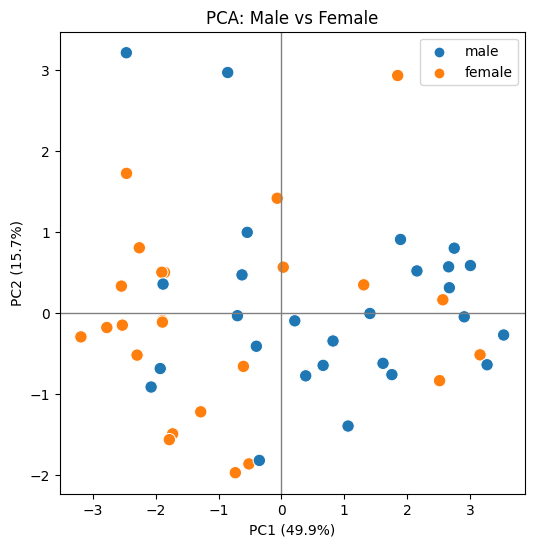

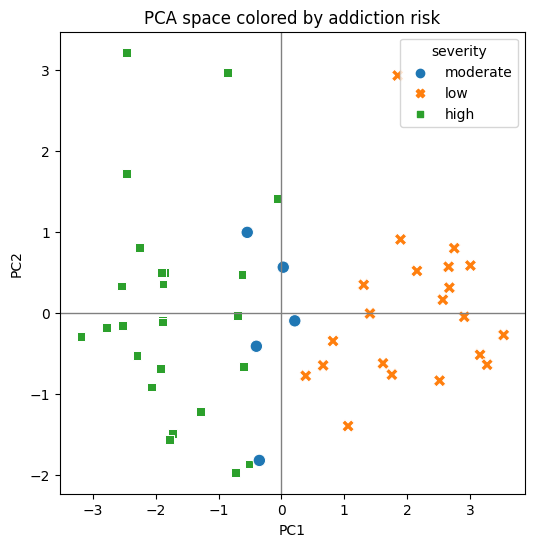


SEX RESULTS


,PC,t,p,p_fdr
0,PC1,3.201843,0.002399,0.011997
1,PC2,0.547481,0.586534,0.586534
2,PC3,1.837719,0.072171,0.180427
3,PC4,-0.956846,0.343343,0.429178
4,PC5,-1.247602,0.218107,0.363511



SEVERITY RESULTS


,PC,F,p,p_fdr
0,PC1,119.094611,2.455337e-19,1.227668e-18
1,PC2,0.050650,9.506622e-01,9.506622e-01
2,PC3,2.214026,1.202986e-01,3.007464e-01
3,PC4,1.151083,3.248699e-01,5.414498e-01
4,PC5,0.242524,7.856004e-01,9.506622e-01


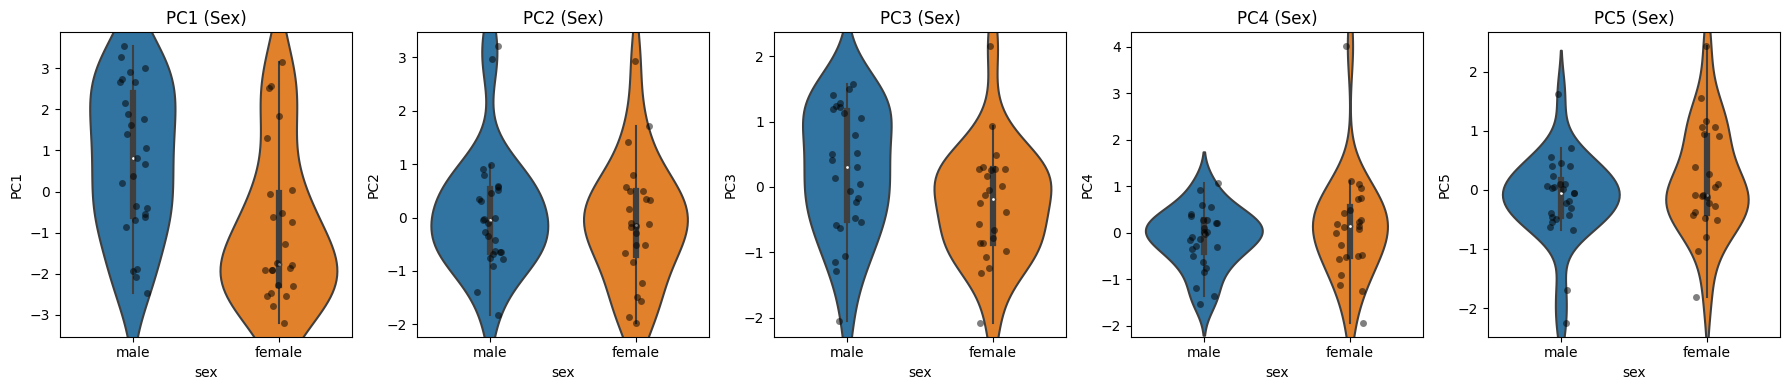

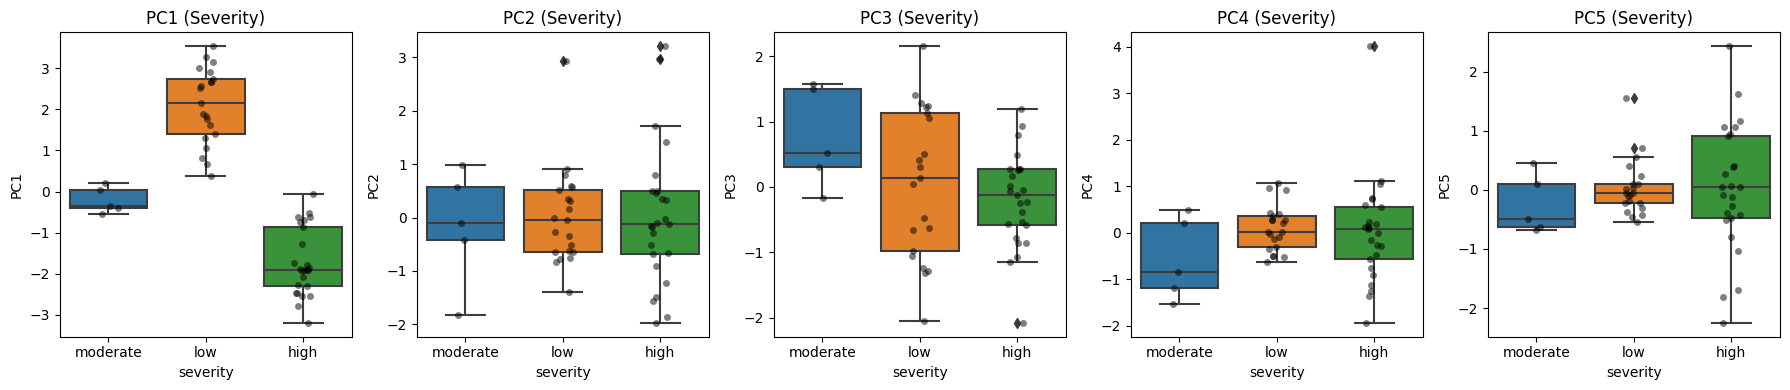

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    PC1   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     45.86
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           1.47e-16
Time:                        15:52:10   Log-Likelihood:                -61.065
No. Observations:                  51   AIC:                             134.1
Df Residuals:                      45   BIC:                             145.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -1.7990      0.201     -8.948      0.000      -2.204      -1.394
C(sex)[T.male]                             0.2920      0.380      0.768      0.446      -0.473       1.057
C(severity)[T.low]                         4.0808      0.431      9.464      0.000       3.212       4.949
C(severity)[T.moderate]                    1.8271      0.876      2.085      0.043       0.062       3.592
C(sex)[T.male]:C(severity)[T.low]         -0.5374      0.579     -0.928      0.358      -1.704       0.629
C(sex)[T.male]:C(severity)[T.moderate]    -0.5916      1.027     -0.576      0.567      -2.659       1.476
==============================================================================
Omnibus:                        1.551   Durbin-Watson:                   2.552
Prob(Omnibus):                  0.461   Jarque-Bera (JB):                1.165
Skew:                           0.113   Prob(JB):                        0.558
Kurtosis:                       2.295   Cond. No.                         14.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [30]:

pca = PCA()
scores = pca.fit_transform(X)



pc_df = pd.DataFrame(
    scores[:, :2],
    columns=["PC1", "PC2"]
)

pc_df["sex"] = df["sex"].values
pc_df["animal"] = df["animal"].values
pc_df["severity"] = df["severity"].values
pc_df["severity_score"] = X.sum(axis=1)


display(pc_df)
pc_df["severity"].value_counts()





plt.figure(figsize=(6,6))

sns.scatterplot(
    data=pc_df,
    x="PC1",
    y="PC2",
    hue="sex",
    s=80
)

plt.axhline(0, color="gray", lw=1)
plt.axvline(0, color="gray", lw=1)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

plt.title("PCA: Male vs Female")
plt.legend()
plt.show()



plt.figure(figsize=(6,6))

sns.scatterplot(
    data=pc_df,
    x="PC1",
    y="PC2",
    hue="severity",
    style="severity",
    s=80
)

plt.axhline(0,color="gray",lw=1)
plt.axvline(0,color="gray",lw=1)

plt.title("PCA space colored by addiction risk")
plt.show()




# -----------------------------
# Build PCA dataframe
# -----------------------------
pc_df = pd.DataFrame(
    scores[:, :5],
    columns=["PC1","PC2","PC3","PC4","PC5"]
)

pc_df["sex"] = df["sex"].values
pc_df["severity"] = df["severity"].values

pcs = ["PC1","PC2","PC3","PC4","PC5"]

# -----------------------------
# SEX: t-tests
# -----------------------------
sex_results = []

for pc in pcs:
    male = pc_df[pc_df["sex"]=="male"][pc]
    female = pc_df[pc_df["sex"]=="female"][pc]

    t, p = ttest_ind(male, female)

    sex_results.append([pc, t, p])

sex_df = pd.DataFrame(sex_results, columns=["PC","t","p"])
sex_df["p_fdr"] = multipletests(sex_df["p"], method="fdr_bh")[1]

print("\nSEX RESULTS")
display(sex_df)

# -----------------------------
# SEVERITY: ANOVA
# -----------------------------
sev_results = []

for pc in pcs:
    groups = [
        pc_df[pc_df["severity"]=="low"][pc],
        pc_df[pc_df["severity"]=="moderate"][pc],
        pc_df[pc_df["severity"]=="high"][pc]
    ]

    F, p = f_oneway(*groups)

    sev_results.append([pc, F, p])

sev_df = pd.DataFrame(sev_results, columns=["PC","F","p"])
sev_df["p_fdr"] = multipletests(sev_df["p"], method="fdr_bh")[1]

print("\nSEVERITY RESULTS")
display(sev_df)

# -----------------------------
# PLOTS: SEX (violin)
# -----------------------------
fig, axes = plt.subplots(1, 5, figsize=(18,4), sharey=False)

for i, pc in enumerate(pcs):
    sns.violinplot(
        data=pc_df,
        x="sex",
        y=pc,
        ax=axes[i]
    )
    sns.stripplot(
        data=pc_df,
        x="sex",
        y=pc,
        color="black",
        alpha=0.5,
        ax=axes[i]
    )
    axes[i].set_title(f"{pc} (Sex)")

plt.tight_layout()
plt.show()

# -----------------------------
# PLOTS: SEVERITY (box)
# -----------------------------
fig, axes = plt.subplots(1, 5, figsize=(18,4), sharey=False)

for i, pc in enumerate(pcs):
    sns.boxplot(
        data=pc_df,
        x="severity",
        y=pc,
        ax=axes[i]
    )
    sns.stripplot(
        data=pc_df,
        x="severity",
        y=pc,
        color="black",
        alpha=0.5,
        ax=axes[i]
    )
    axes[i].set_title(f"{pc} (Severity)")

plt.tight_layout()
plt.show()


smf.ols("PC1 ~ C(sex) * C(severity)", data=pc_df).fit().summary()

[0.49892791 0.15738737 0.11303596 0.10161573 0.08475909 0.02182667
 0.01496824 0.00747902]
[0.49892791 0.65631528 0.76935125 0.87096698 0.95572607 0.97755274
 0.99252098 1.        ]


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
intake,0.444,-0.273,0.154,0.086,0.123,-0.296,0.716,0.286
consistency,0.440,-0.225,0.310,-0.200,-0.082,0.180,-0.008,-0.762
avg infusion latency,0.433,-0.229,0.197,-0.331,-0.046,0.290,-0.456,0.563
extinction lever presses,0.365,0.391,-0.360,0.302,-0.061,0.658,0.236,0.029
seeking,0.358,-0.013,0.014,0.712,-0.207,-0.376,-0.423,-0.033
reinstatement,0.291,0.390,-0.099,-0.147,0.795,-0.233,-0.191,-0.088
motivation,0.223,0.594,-0.005,-0.410,-0.538,-0.367,0.067,0.030
days for 10 infusions,0.160,-0.405,-0.838,-0.234,-0.086,-0.179,-0.064,-0.099


,PC,eigenvalue,% variance,cumulative %
0,PC1,3.991,49.893,49.893
1,PC2,1.259,15.739,65.632
2,PC3,0.904,11.304,76.935
3,PC4,0.813,10.162,87.097
4,PC5,0.678,8.476,95.573
5,PC6,0.175,2.183,97.755
6,PC7,0.120,1.497,99.252
7,PC8,0.060,0.748,100.000


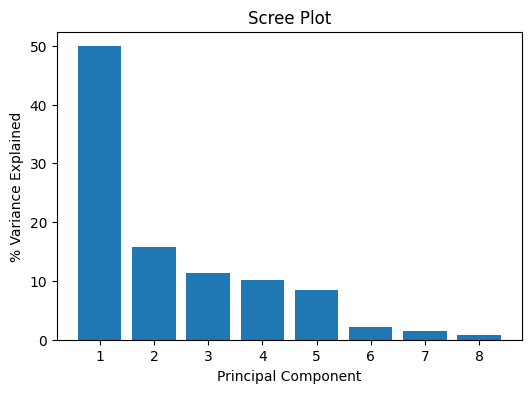

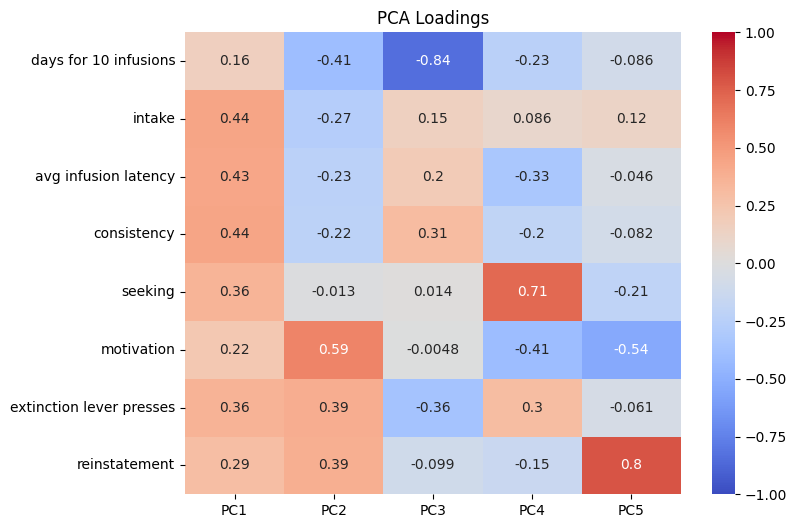

,PC1,PC2,PC3,PC4,PC5
days for 10 infusions,0.32,-0.45,-0.80,-0.21,-0.07
intake,0.89,-0.31,0.15,0.08,0.10
avg infusion latency,0.87,-0.26,0.19,-0.30,-0.04
consistency,0.88,-0.25,0.29,-0.18,-0.07
seeking,0.72,-0.01,0.01,0.64,-0.17
motivation,0.45,0.67,-0.00,-0.37,-0.44
extinction lever presses,0.73,0.44,-0.34,0.27,-0.05
reinstatement,0.58,0.44,-0.09,-0.13,0.65


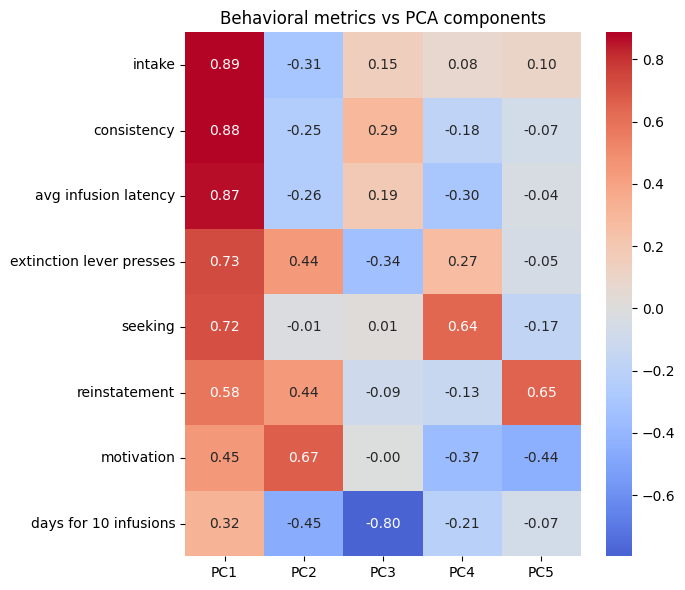

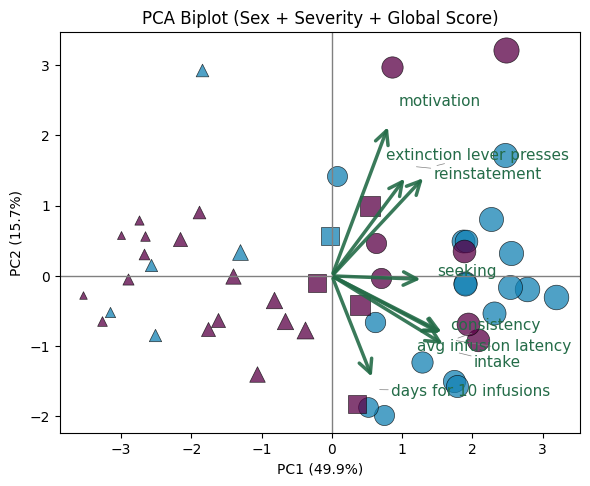

In [45]:



# Variance explained by each PC
print(pca.explained_variance_ratio_)

# Cumulative variance explained
print(np.cumsum(pca.explained_variance_ratio_))

loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(len(X.columns))]
)
scores[:, 0] *= -1
loadings["PC1"] *= -1
loadings_sorted=loadings.sort_values("PC1", ascending=False)
display(loadings_sorted.round(3))


#####################
# summary table
# eigenvalues
eigvals = pca.explained_variance_

# variance ratio
var_ratio = pca.explained_variance_ratio_

# cumulative variance
cum_var = np.cumsum(var_ratio)

# build dataframe
pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(eigvals))],
    "eigenvalue": eigvals,
    "% variance": var_ratio * 100,
    "cumulative %": cum_var * 100
})

display(pca_summary.round(3))
#####################



var = pca.explained_variance_ratio_

plt.figure(figsize=(6,4))
plt.bar(range(1, len(var)+1), var*100)
plt.xlabel("Principal Component")
plt.ylabel("% Variance Explained")
plt.title("Scree Plot")
plt.show()

plt.figure(figsize=(8,6))

sns.heatmap(
    loadings.iloc[:,0:5],
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("PCA Loadings")
plt.show()



#######################
# how much does each behavioral metric contribute to each PC?

# clean column names (important for your dataset)
X.columns = X.columns.str.replace('\xa0', ' ', regex=False).str.strip()

pcs = pc_df[["PC1","PC2","PC3","PC4","PC5"]]#,"PC6","PC7","PC8"]]

# combine raw + PCs
combined = pd.concat([X, pcs], axis=1)

# correlation: metrics vs PCs
metric_pc_corr = combined.corr().loc[
    X.columns,
    ["PC1","PC2","PC3","PC4","PC5"]#,"PC6","PC7","PC8"]
]

display(metric_pc_corr.round(2))
metric_pc_corr_sorted = metric_pc_corr.sort_values("PC1", ascending=False)

# heatmap
plt.figure(figsize=(7,6))
sns.heatmap(
    metric_pc_corr_sorted,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Behavioral metrics vs PCA components")
plt.tight_layout()
plt.show()

#####################




def biplot(scores, loadings, labels, metadata, save_path, pc1=0, pc2=1):

    fig, ax = plt.subplots(figsize=(6,6))

    # -----------------------
    # COLORS (SEX)
    # -----------------------
    sex_colors = {
        "male": (90/255, 0/255, 70/255),
        "female": (20/255, 130/255, 180/255)
    }

    green = (36/255, 108/255, 72/255)

    # -----------------------
    # SHAPES (SEVERITY CATEGORY)
    # -----------------------
    severity_markers = {
        "low": "^",
        "moderate": "s",
        "high": "o"
    }

    # -----------------------
    # SIZE SCALING (SEVERITY SCORE)
    # -----------------------
    sev = metadata["severity_score"].values

    sizes = 30 + 300 * (sev - np.min(sev)) / (np.max(sev) - np.min(sev))

    # -----------------------
    # SCORE PLOT
    # -----------------------
    for i in range(len(scores)):
        ax.scatter(
            scores[i, pc1],
            scores[i, pc2],
            color=sex_colors.get(metadata["sex"].iloc[i], "gray"),
            marker=severity_markers.get(metadata["severity"].iloc[i], "x"),
            s=sizes[i],
            alpha=0.75,
            edgecolor="black",
            linewidth=0.5
        )

    # -----------------------
    # SCALE LOADINGS
    # -----------------------
    xs = scores[:, pc1]
    ys = scores[:, pc2]

    scale = 0.7 * min(
        np.max(xs) - np.min(xs),
        np.max(ys) - np.min(ys)
    )

    # -----------------------
    # LOADINGS (ARROWS + LABELS)
    # -----------------------
    texts = []

    for i, var in enumerate(labels):

        x_end = loadings[i, pc1] * scale
        y_end = loadings[i, pc2] * scale

        # thicker arrow with better control
        ax.annotate(
            "",
            xy=(x_end, y_end),
            xytext=(0, 0),
            arrowprops=dict(
                arrowstyle="->",
                color=green,
                lw=2.5,
                mutation_scale=24,
                alpha=0.9
            )
        )

        # label (to be adjusted later)
        texts.append(
            ax.text(
                x_end * 1.1,
                y_end * 1.1,
                var,
                color=green,
                fontsize=11
            )
        )

    # -----------------------
    # AUTOMATIC LABEL REPULSION
    # -----------------------
    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
    )

    # -----------------------
    # AXES
    # -----------------------
    ax.axhline(0, color='gray', lw=1)
    ax.axvline(0, color='gray', lw=1)

    ax.set_xlabel(f"PC{pc1+1} ({pca.explained_variance_ratio_[pc1]*100:.1f}%)")
    ax.set_ylabel(f"PC{pc2+1} ({pca.explained_variance_ratio_[pc2]*100:.1f}%)")

    ax.set_title("PCA Biplot (Sex + Severity + Global Score)")

    ax.set_aspect("equal")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, format="svg", bbox_inches="tight")

    plt.show()


metadata = df[["sex","severity"]].copy()
metadata["severity_score"] = X.sum(axis=1)

biplot(
    scores,
    pca.components_.T,
    X.columns,
    metadata,
    save_path="pca_biplot.svg"
)


#######################
# saving

# PCA summary table

pca_summary.to_csv("pca_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(6,2))
ax.axis('off')

table = ax.table(
    cellText=pca_summary.round(3).values,
    colLabels=pca_summary.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.savefig("pca_summary.svg", format="svg", bbox_inches="tight")
plt.close()


# correlation matrix

plt.figure(figsize=(5,4))

sns.heatmap(
    metric_pc_corr_sorted,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Behavioral metrics vs PCA components")

plt.tight_layout()

plt.savefig("pca_metric_pc_correlation.svg", format="svg", bbox_inches="tight")
plt.close()

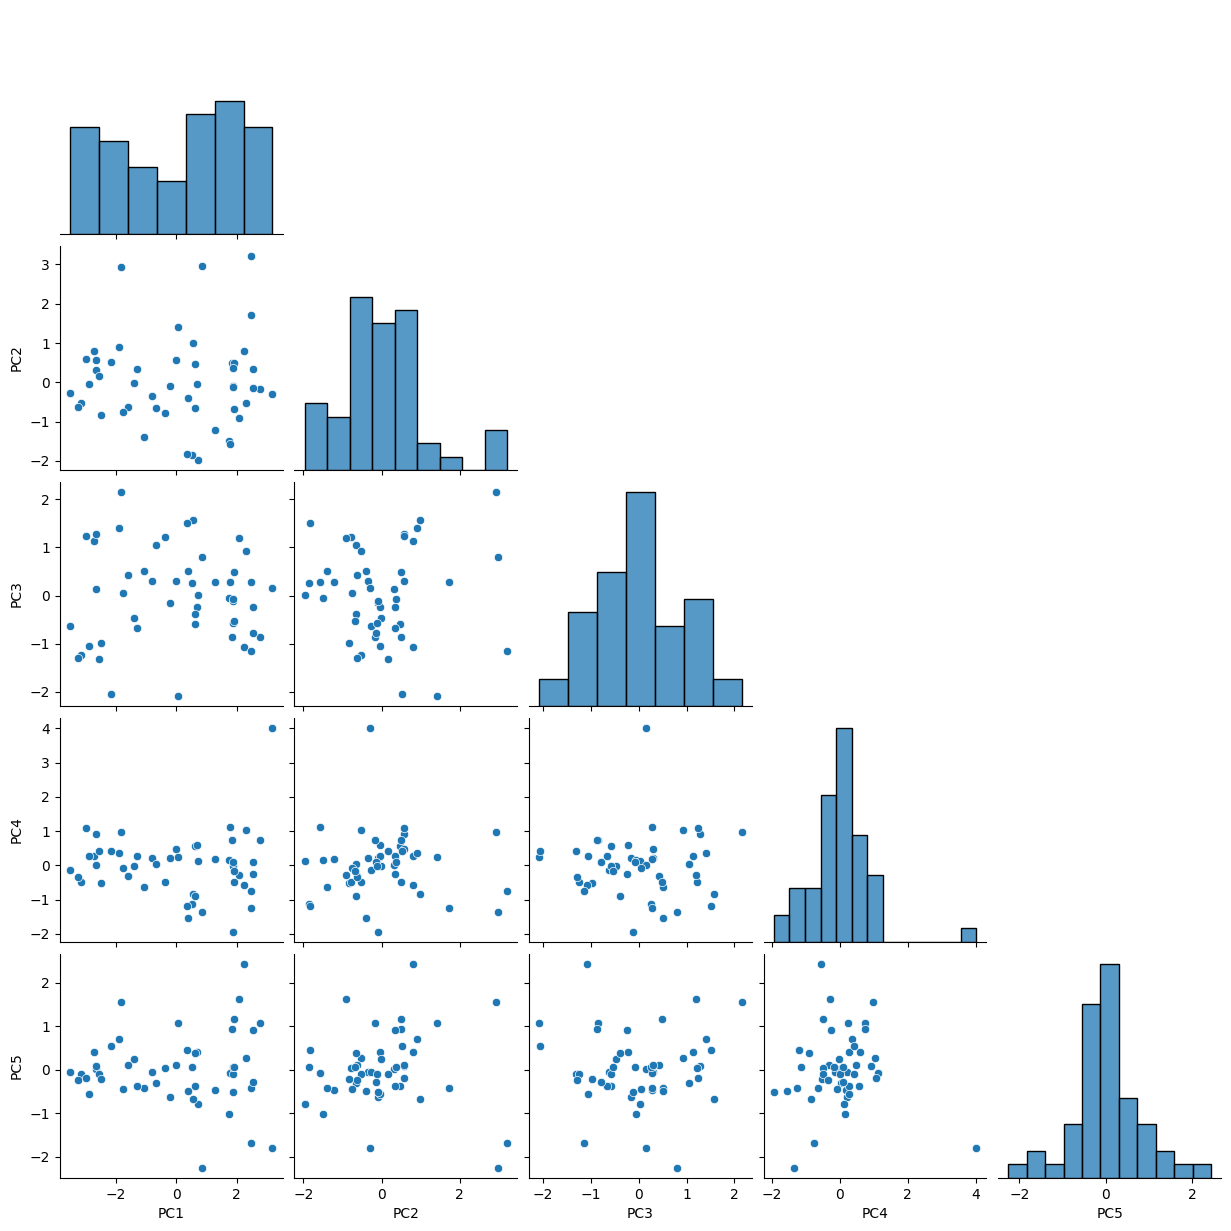

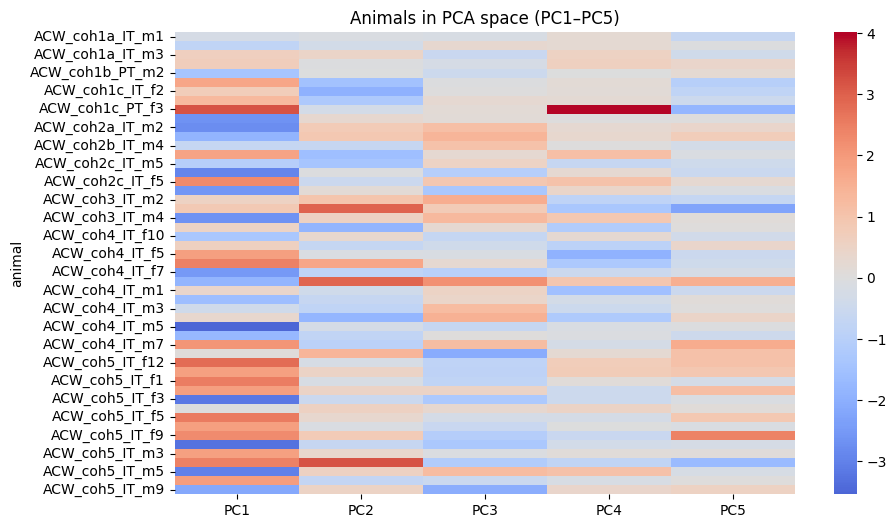

<AxesSubplot:xlabel='PC1', ylabel='PC2'>

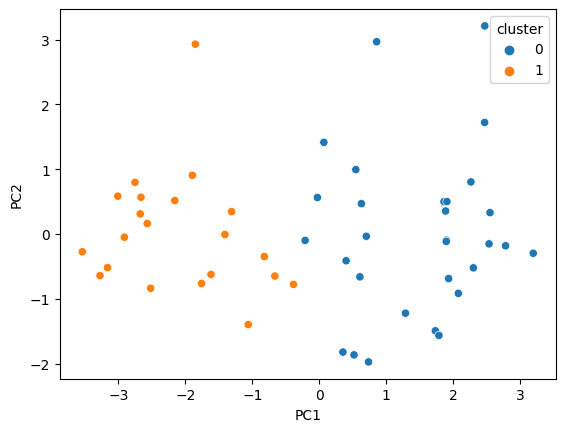

In [29]:
pc_df = pd.DataFrame(
    scores,
    columns=[f"PC{i+1}" for i in range(scores.shape[1])]
)

pc_df["animal"] = df["animal"].values

pc_df


sns.pairplot(
    pc_df[["PC1","PC2","PC3","PC4","PC5"]],
    corner=True
)

pc_df.corr()


plt.figure(figsize=(10,6))

sns.heatmap(
    pc_df.set_index("animal")[["PC1","PC2","PC3","PC4","PC5"]],
    cmap="coolwarm",
    center=0
)

plt.title("Animals in PCA space (PC1–PC5)")
plt.show()

from sklearn.cluster import KMeans

X_pca5 = pc_df[["PC1","PC2","PC3","PC4","PC5"]]

kmeans = KMeans(n_clusters=2, random_state=0).fit(X_pca5)

pc_df["cluster"] = kmeans.labels_



In [73]:


from scipy.stats import pearsonr

for var in ["reinstatement","extinction lever presses","motivation"]:
    print(var)
    for pc in ["PC1","PC2","PC3","PC4","PC5"]:
        r, p = pearsonr(pc_df[pc], X[var])
        print(pc, r)

reinstatement
PC1 0.5817728880247712
PC2 0.4378166090461353
PC3 -0.09395958329442641
PC4 -0.13287558962527107
PC5 0.6549972590643566
extinction lever presses
PC1 0.7286383163632514
PC2 0.4390170759336637
PC3 -0.34250561948292163
PC4 0.27242372105282375
PC5 -0.050570258358307335
motivation
PC1 0.44573748167586125
PC2 0.6665374100630546
PC3 -0.00460971019452748
PC4 -0.3699826644150307
PC5 -0.44280177612273486
